In [2]:
# General
import qiskit
import numpy as np
import scipy as sp
import functools as ft
import json

# Qiskit imports
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.circuit import Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumRegister, AncillaRegister
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator, Pauli

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck



In [3]:
def hamiltonian1(L, Jz):
    """
    Docstring for hamiltonian
    
    :param X: X pauli op
    (X, 0, t)
    :param Y: Y pauli op
    :param Z: Z pauli op
    """
    ham_list = []

    for i in range (int(L)-1):
        ham_list.append(("XX", [i, i+1], -1)) # XX bc Xi and X i+1
        ham_list.append(("YY", [i, i+1], -1))
        ham_list.append(("ZZ", [i, i+1], -Jz))

    H =  SparsePauliOp.from_sparse_list(ham_list, num_qubits=L)

    return H

In [4]:
def initialise(Jz, L, allzeros, rotate_middle=True):
    """
    Return the initial Statevector for the given Jz regime.

    :param Jz: (float) anisotropy; must satisfy |Jz| > 1
    :param L:  (int) number of qubits
    :param allzeros: (bool)  for Jz > 1: True → |000…⟩, False → |111…⟩
    :param rotate_middle:(bool) if True, apply Ry(π/2) to qubit L//2
    :returns:            Statevector of the initial state
    """
    if Jz > 1:
        if allzeros:
            sv = Statevector.from_label("0" * L)
        else:
            sv = Statevector.from_label("1" * L)
    elif Jz < -1:
        alternating = "".join(["10"[i % 2] for i in range(L)])
        sv = Statevector.from_label(alternating)
    else:
        raise ValueError("Jz must be > 1 or < -1")

    #rotation is done at this stage bc trotter method can work with it out this function but mchlachan cannot
    if rotate_middle:
        middle = L // 2
        qc_rot = QuantumCircuit(L)
        qc_rot.ry(np.pi / 2, middle)
        sv = sv.evolve(Operator(qc_rot))   

    return sv


In [5]:
def ClassicalComparison(L, Jz, qubit_measured, direction_measured, steps=100, t_tot=1, allzeros=True):
    '''
    performs an expectation value measurement for a spin proj. in a certain direction on a certain qubit. Does this classically with matrix multiplication.
    (still need to make the initial state rotation classical) (rn, importing Hamiltonian.py as hm) (imports needed: scipy as sp, numpy as np, functools as ft)
    
    returns two np.arrays: ([time_values],[measurements])

    :param L: (int) number of qubits
    :param Jz: (float) J_z value 
    :param qubit_measured: (int) which qubit (1 to L) is measured
    :param direction_measured: (str) "X" "Y" or "Z", which projection operator is applied to the measured qubit
    :param steps: (int) number of time steps (auto set to 100)
    :param t_tot: (float) total time (in seconds? not seconds cause there are no hbars or cs) (auto set to 1)
    :param allzeros: (bool) if Jz>1, True chooses the all |0> state, False chooses the all |1> state
    '''

    #Hamiltonian as an np.array matrix
    matrix_h = np.array(hamiltonian1(L, Jz))

    #getting initial state, according to Jz value
    psi0 = np.array(initialise(Jz, L, allzeros, rotate_middle=True))

    #choosing correct pauli matrix
    pauli_x  = np.array([[0,  1 ], [1,   0]], dtype=complex)
    pauli_y  = np.array([[0, -1j], [1j,  0]], dtype=complex)
    pauli_z  = np.array([[1,  0 ], [0,  -1]], dtype=complex)
    pauli_map = {"x": pauli_x, "y": pauli_y, "z": pauli_z}

    pauli = pauli_map.get(direction_measured.lower())
    if pauli is None:
        raise ValueError("Please choose strings 'X', 'Y', or 'Z' for direction_measured")

    #creating our observable operator matrix, for our expectation value
    product = [np.eye(2) for i in range(L)]
    product[qubit_measured-1] = pauli          #list of matrices to kronecker product to build the observable matrix
    observable_m = ft.reduce(np.kron, product) #does multiple kronecker products in a row (with matrices in list)

    # Initialise an empty list to store the observables we compute
    measurements = []

    #timestep
    dt = t_tot / steps

    # Run a loop over timesteps
    for t in range(steps):
        Ut = sp.linalg.expm(-1j * matrix_h * dt * t)
        psi_t = Ut @ psi0
        expval = psi_t.conj().T @ observable_m @ psi_t
        measurements += [expval.real]

    t_values = np.array([dt * t for t in range(steps)])

    return (t_values, np.array(measurements))

In [6]:
def PhysicalST(L, Jz, qubit_measured, direction_measured,t_tot,steps=100,  allzeros=True, order=1, reps=5):
    """
    Qiskit Suzuki-Trotter: fixed-depth circuit (hardware-compatible).
    Rebuilds a fresh circuit for each time point, keeping circuit depth constant.
    This is the method submitted to IBM quantum hardware.

    :param L:                  (int)   number of qubits
    :param Jz:                 (float) anisotropy parameter
    :param qubit_measured:     (int)   qubit index (1-based)
    :param direction_measured: (str)   'X', 'Y', or 'Z'
    :param steps:              (int)   number of time points sampled
    :param t_tot:              (float) total evolution time
    :param order:              (int)   Suzuki–Trotter order (default 1)
    :param reps:               (int)   fixed circuit depth in Trotter steps (default 5)
    :param allzeros:           (bool)  for Jz>1: True→|000…⟩
    :returns: (t_values, measurements) as np.arrays
    """
    hamiltonian = hamiltonian1(L, Jz)
    st = SuzukiTrotter(order=order, reps=reps, preserve_order=False)

    paulistring = "".join(
        direction_measured if i == qubit_measured - 1 else "I" for i in range(L)
    )
    obs       = SparsePauliOp([paulistring], coeffs=[1])
    estimator = StatevectorEstimator()   # replace with IBM Estimator to run on hardware
    
    psi0    = initialise(Jz, L, allzeros=allzeros, rotate_middle=True)
    dt      = t_tot / steps
    t_values = np.array([dt * t for t in range(steps)])

    measurements = []
    for timeval in t_values:
        gate = PauliEvolutionGate(operator=hamiltonian, time=timeval)
        circ = st.synthesize(gate)
        qc   = QuantumCircuit(L)
        qc.initialize(psi0.data)
        qc.append(circ, range(L))
        result = estimator.run(pubs=[(qc, [obs])]).result()
        measurements.append(result[0].data.evs[0])

    return t_values, np.array(measurements)

In [7]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService, Session
try:
    with open('apikey3.json') as file:
        api_key = json.load(file)
except:
    print("No API key found: make sure to modify this code and enter your API key manually in the below command.")

In [9]:
QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance="open-instance", token=api_key["apikey"], overwrite=True, set_as_default=True)

# # Load saved credentials
service = QiskitRuntimeService()

# # Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

L=5
Jz=1.1
reps=10
qubit_measured = 3
direction_measured = 'X'

#creating hamiltonian
hamiltonian = hamiltonian1(L,Jz)

#Setting order and reps of SuzukiTrotter method
st = SuzukiTrotter(order=1, reps=reps)

psi0 = initialise(Jz, L, allzeros=True, rotate_middle=True)

# Define the observable we wish to estimate
paulistring=""
for i in range(L):
     if i == qubit_measured - 1:
         paulistring+=direction_measured
     else:
         paulistring+="I"
obs = SparsePauliOp([paulistring],coeffs=[1])



target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)


estimator = Estimator(mode=backend)

#t_values = np.log10(np.array(range(1,100,10)))
t_values = np.logspace(-2, np.log10(5), 10)






In [10]:
xmeasurements=[]
for timeval in t_values:
        gate = PauliEvolutionGate(operator=hamiltonian, time=timeval)
        circ = st.synthesize(gate)
        qc   = QuantumCircuit(L)
        qc.initialize(psi0.data)
        qc.append(circ, range(L))
        isa_qc = pm.run(qc)
        isa_obs = obs.apply_layout(isa_qc.layout)
        result = estimator.run(pubs=[(isa_qc, [isa_obs])]).result()
        xmeasurements.append(result[0].data.evs[0]) 



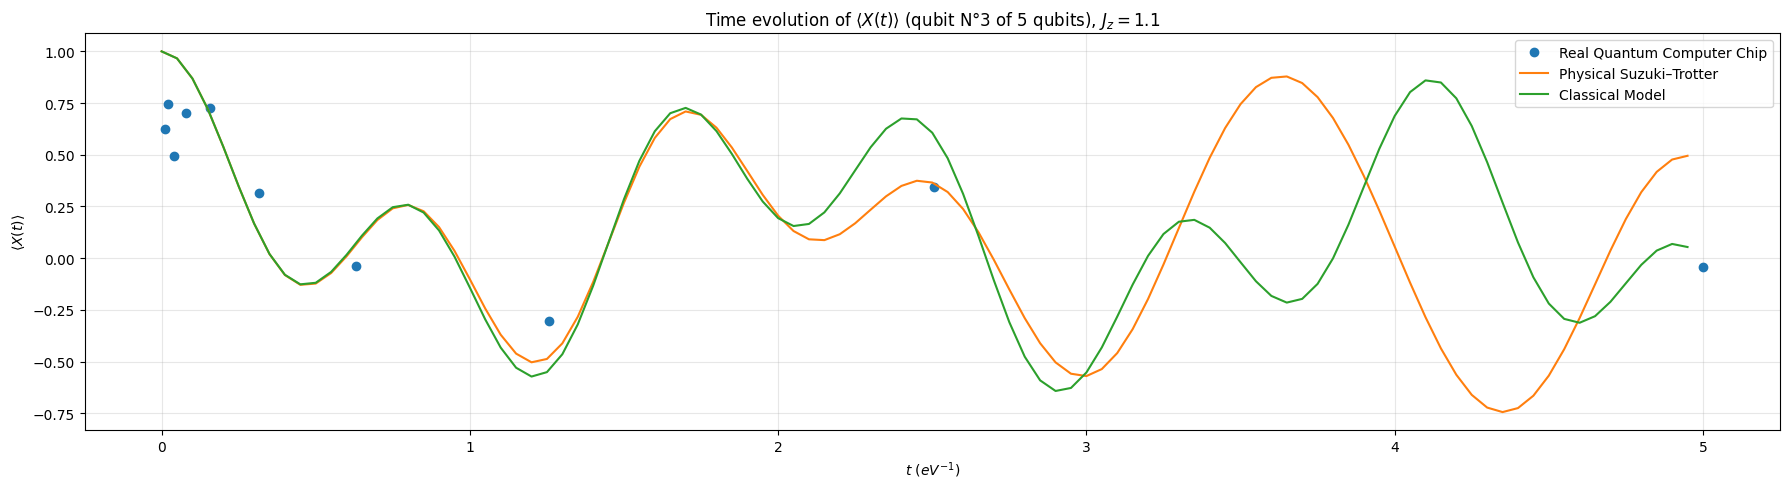

In [12]:
tclass,classic = ClassicalComparison(L,Jz,qubit_measured,direction_measured,t_tot=t_values[-1])
tphys, phys = PhysicalST(L, Jz, qubit_measured, direction_measured,t_tot=t_values[-1])

plt.figure(figsize=(18,5))

# Data from quantum hardware
plt.plot(t_values, xmeasurements, 'o', label="Real Quantum Computer Chip")
# Suzuki–Trotter physical simulation
plt.plot(tphys, phys, label="Physical Suzuki–Trotter")
# Classical model
plt.plot(tclass, classic, label="Classical Model")

plt.xlabel(r'$t\ (eV^{-1})$')
plt.ylabel(rf'$\langle {direction_measured}(t) \rangle$')
plt.title(rf'Time evolution of $\langle {direction_measured}(t) \rangle$ (qubit N°{qubit_measured} of 5 qubits), $J_z={Jz}$')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance="open-instance", token=api_key["apikey"], overwrite=True, set_as_default=True)

# # Load saved credentials
service = QiskitRuntimeService()

# # Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

L=5
Jz=1.1
reps=10
qubit_measured = 3
direction_measured = 'Y'

#creating hamiltonian
hamiltonian = hamiltonian1(L,Jz)

#Setting order and reps of SuzukiTrotter method
st = SuzukiTrotter(order=1, reps=reps)

psi0 = initialise(Jz, L, allzeros=True, rotate_middle=True)

# Define the observable we wish to estimate
paulistring=""
for i in range(L):
     if i == qubit_measured - 1:
         paulistring+=direction_measured
     else:
         paulistring+="I"
obs = SparsePauliOp([paulistring],coeffs=[1])



target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)


estimator = Estimator(mode=backend)


t_values = np.logspace(-2, np.log10(5), 10)






In [ ]:
ymeasurements=[]
for timeval in t_values:
        gate = PauliEvolutionGate(operator=hamiltonian, time=timeval)
        circ = st.synthesize(gate)
        qc   = QuantumCircuit(L)
        qc.initialize(psi0.data)
        qc.append(circ, range(L))
        isa_qc = pm.run(qc)
        isa_obs = obs.apply_layout(isa_qc.layout)
        result = estimator.run(pubs=[(isa_qc, [isa_obs])]).result()
        ymeasurements.append(result[0].data.evs[0]) 



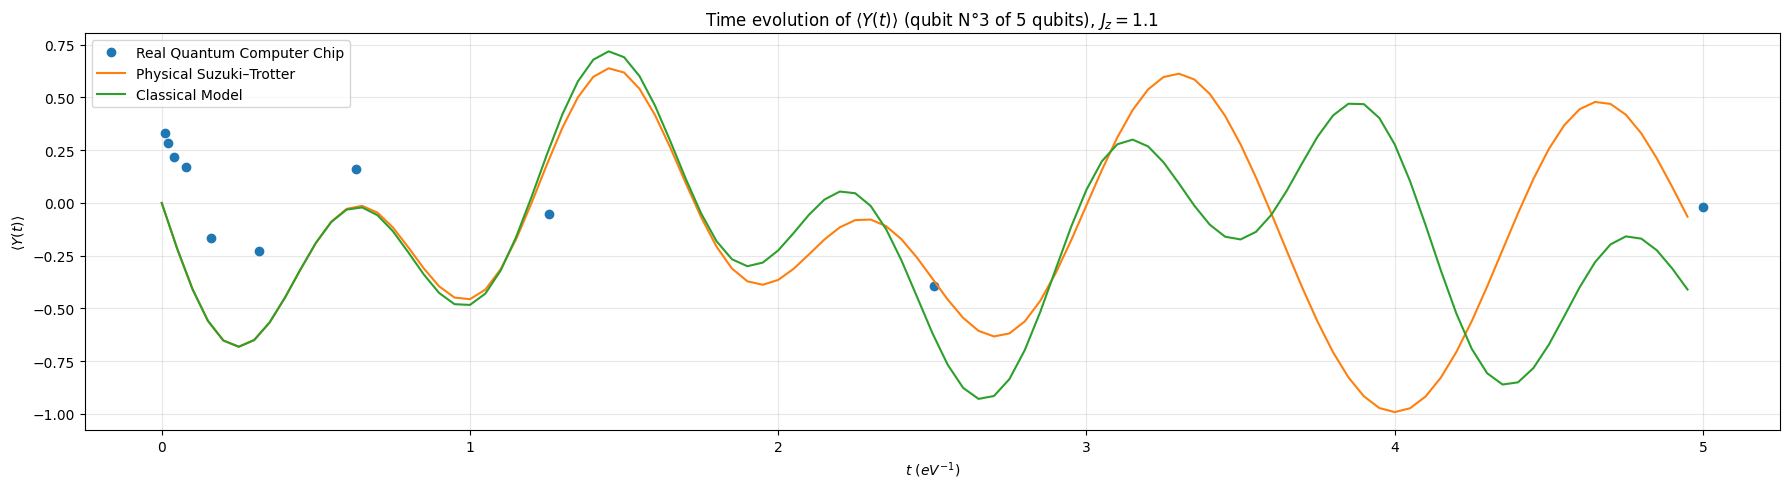

In [16]:
tclass,classic = ClassicalComparison(L,Jz,qubit_measured,direction_measured,t_tot=t_values[-1])
tphys, phys = PhysicalST(L, Jz, qubit_measured, direction_measured,t_tot=t_values[-1])

plt.figure(figsize=(18,5))

# Data from quantum hardware
plt.plot(t_values, ymeasurements, 'o', label="Real Quantum Computer Chip")
# Suzuki–Trotter physical simulation
plt.plot(tphys, phys, label="Physical Suzuki–Trotter")
# Classical model
plt.plot(tclass, classic, label="Classical Model")

plt.xlabel(r'$t\ (eV^{-1})$')
plt.ylabel(rf'$\langle {direction_measured}(t) \rangle$')
plt.title(rf'Time evolution of $\langle {direction_measured}(t) \rangle$ (qubit N°{qubit_measured} of 5 qubits), $J_z={Jz}$')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance="open-instance", token=api_key["apikey"], overwrite=True, set_as_default=True)

# # Load saved credentials
service = QiskitRuntimeService()

# # Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

L=5
Jz=1.1
reps=10
qubit_measured = 3
direction_measured = 'Y'

#creating hamiltonian
hamiltonian = hamiltonian1(L,Jz)

#Setting order and reps of SuzukiTrotter method
st = SuzukiTrotter(order=1, reps=reps)

psi0 = initialise(Jz, L, allzeros=True, rotate_middle=True)

# Define the observable we wish to estimate
paulistring=""
for i in range(L):
     if i == qubit_measured - 1:
         paulistring+=direction_measured
     else:
         paulistring+="I"
obs = SparsePauliOp([paulistring],coeffs=[1])



target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)


estimator = Estimator(mode=backend)


t_valueslin = np.linspace(0, 5, 15)






In [19]:
ymeasurementslin=[]
for timeval in t_valueslin:
        gate = PauliEvolutionGate(operator=hamiltonian, time=timeval)
        circ = st.synthesize(gate)
        qc   = QuantumCircuit(L)
        qc.initialize(psi0.data)
        qc.append(circ, range(L))
        isa_qc = pm.run(qc)
        isa_obs = obs.apply_layout(isa_qc.layout)
        result = estimator.run(pubs=[(isa_qc, [isa_obs])]).result()
        ymeasurementslin.append(result[0].data.evs[0]) 



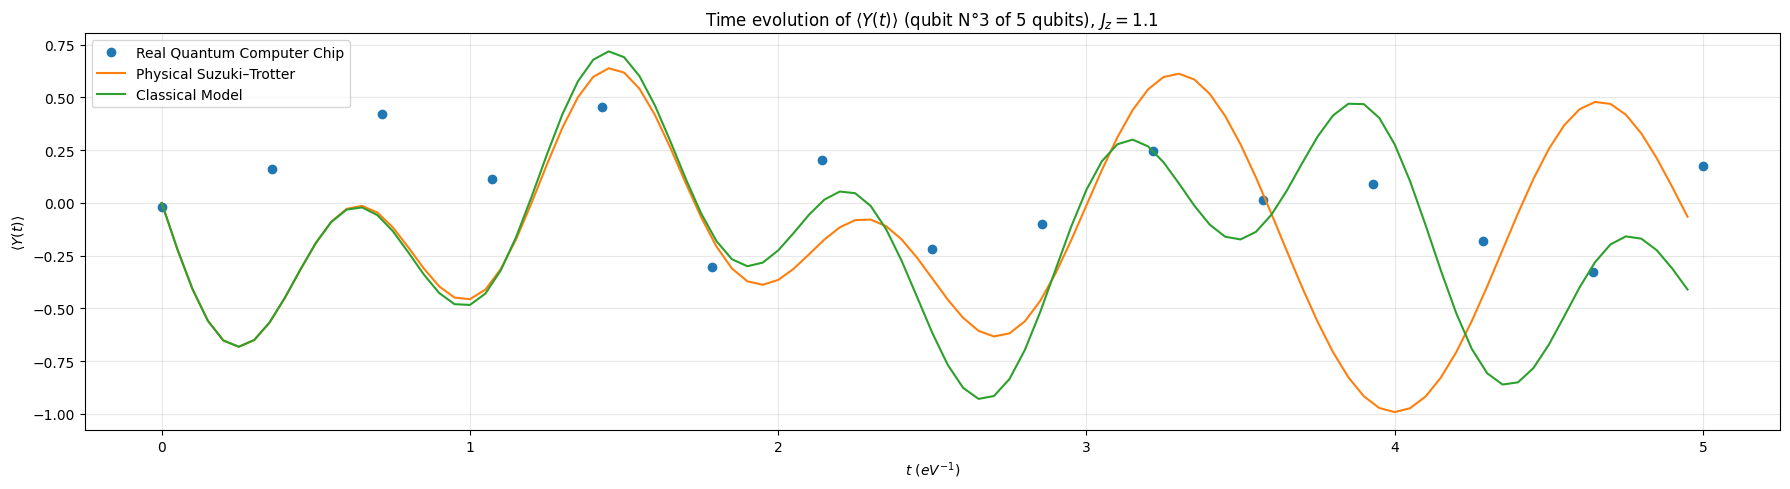

In [20]:
tclass,classic = ClassicalComparison(L,Jz,qubit_measured,direction_measured,t_tot=t_valueslin[-1])
tphys, phys = PhysicalST(L, Jz, qubit_measured, direction_measured,t_tot=t_valueslin[-1])

plt.figure(figsize=(18,5))

# Data from quantum hardware
plt.plot(t_valueslin, ymeasurementslin, 'o', label="Real Quantum Computer Chip")
# Suzuki–Trotter physical simulation
plt.plot(tphys, phys, label="Physical Suzuki–Trotter")
# Classical model
plt.plot(tclass, classic, label="Classical Model")

plt.xlabel(r'$t\ (eV^{-1})$')
plt.ylabel(rf'$\langle {direction_measured}(t) \rangle$')
plt.title(rf'Time evolution of $\langle {direction_measured}(t) \rangle$ (qubit N°{qubit_measured} of 5 qubits), $J_z={Jz}$')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance="open-instance", token=api_key["apikey"], overwrite=True, set_as_default=True)

# # Load saved credentials
service = QiskitRuntimeService()

# # Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

L=5
Jz=1.1
reps=10
qubit_measured = 3
direction_measured = 'X'

#creating hamiltonian
hamiltonian = hamiltonian1(L,Jz)

#Setting order and reps of SuzukiTrotter method
st = SuzukiTrotter(order=1, reps=reps)

psi0 = initialise(Jz, L, allzeros=True, rotate_middle=True)

# Define the observable we wish to estimate
paulistring=""
for i in range(L):
     if i == qubit_measured - 1:
         paulistring+=direction_measured
     else:
         paulistring+="I"
obs = SparsePauliOp([paulistring],coeffs=[1])



target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)


estimator = Estimator(mode=backend)

#t_values = np.log10(np.array(range(1,100,10)))
t_values = np.logspace(-2, np.log10(5), 10)






In [ ]:
zmeasurements=[]
for timeval in t_valueslin:
        gate = PauliEvolutionGate(operator=hamiltonian, time=timeval)
        circ = st.synthesize(gate)
        qc   = QuantumCircuit(L)
        qc.initialize(psi0.data)
        qc.append(circ, range(L))
        isa_qc = pm.run(qc)
        isa_obs = obs.apply_layout(isa_qc.layout)
        result = estimator.run(pubs=[(isa_qc, [isa_obs])]).result()
        zmeasurements.append(result[0].data.evs[0]) 



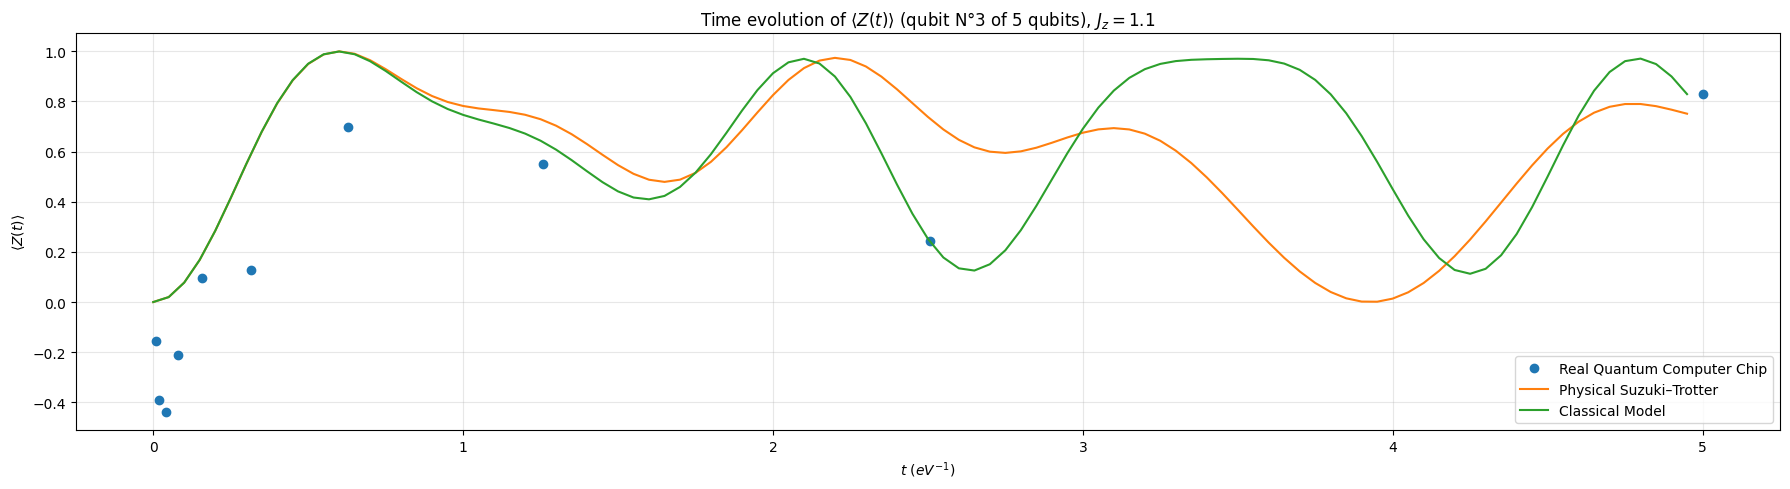

In [ ]:
tclass,zclass = ClassicalComparison(L,Jz,qubit_measured,direction_measured,t_tot=t_values[-1])
tphys, zphys = PhysicalST(L, Jz, qubit_measured, direction_measured,t_tot=t_values[-1])

plt.figure(figsize=(18,5))

# Data from quantum hardware
plt.plot(t_values, zmeasurements, 'o', label="Real Quantum Computer Chip")
# Suzuki–Trotter physical simulation
plt.plot(tphys, zphys, label="Physical Suzuki–Trotter")
# Classical model
plt.plot(tclass, zclass, label="Classical Model")

plt.xlabel(r'$t\ (eV^{-1})$')
plt.ylabel(rf'$\langle {direction_measured}(t) \rangle$')
plt.title(rf'Time evolution of $\langle {direction_measured}(t) \rangle$ (qubit N°{qubit_measured} of 5 qubits), $J_z={Jz}$')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
#        gate = PauliEvolutionGate(operator=hamiltonian, time=1)
#
#        circ = st.synthesize(gate)
#        qc   = QuantumCircuit(L)
#        qc.initialize(psi0.data)
#        qc.append(circ, range(L))
#        isa_qc = pm.run(qc)
#        isa_obs = obs.apply_layout(isa_qc.layout)
#        result = estimator.run(pubs=[(isa_qc, [isa_obs])]).result()
#        measurements.append(result[0].data.evs[0]) 
#
#        print(isa_obs.num_qubits)
#        print(isa_qc.num_qubits)
